In [1]:
import matplotlib.pyplot as plt
from reliability.Fitters import Fit_Everything
from import_data import df_train
from reliability.Distributions import Loglogistic_Distribution

c:\Users\julia\anaconda3\envs\my_reliability_env\lib\site-packages\reliability\Fitters.py:440: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(


Results from Fit_Everything:
Analysis method: MLE
Failures / Right censored: 100/0 (0% right censored) 

   Distribution   Alpha    Beta   Gamma Alpha 1  Beta 1 Alpha 2  Beta 2 Proportion 1 DS      Mu    Sigma     Lambda  Log-likelihood    AICc     BIC       AD optimizer
   Lognormal_2P                                                                         5.30624 0.212116                   -517.456 1039.04 1044.12 0.820625       TNC
 Loglogistic_2P 199.813  8.3708                                                                                            -517.743 1039.61  1044.7 0.694054       TNC
       Gamma_3P  22.619 4.11708 113.186                                                                                    -515.929 1038.11 1045.67 0.625141       TNC
   Lognormal_3P                 80.9653                                                 4.76702 0.358224                   -515.936 1038.12 1045.69 0.570459       TNC
 Loglogistic_3P  108.44  4.5404 89.8571                     

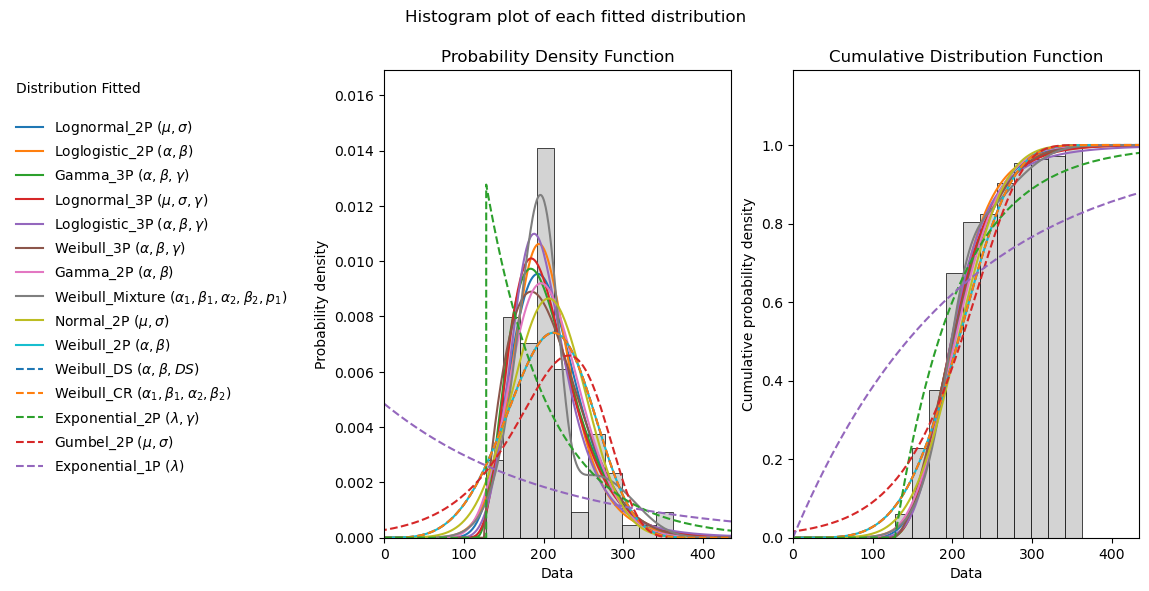

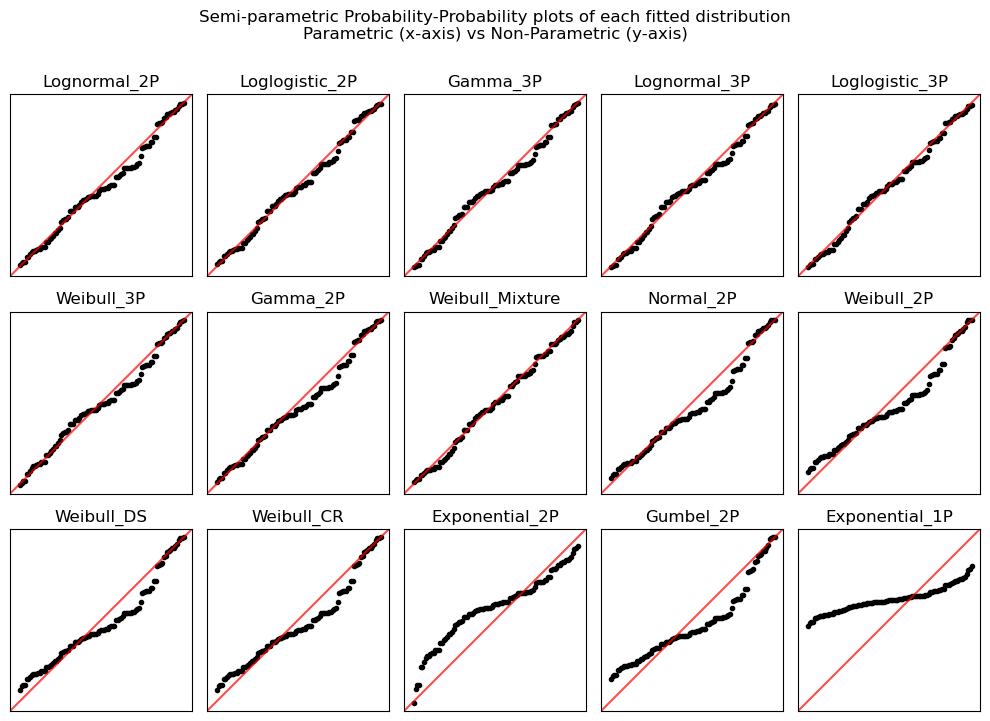

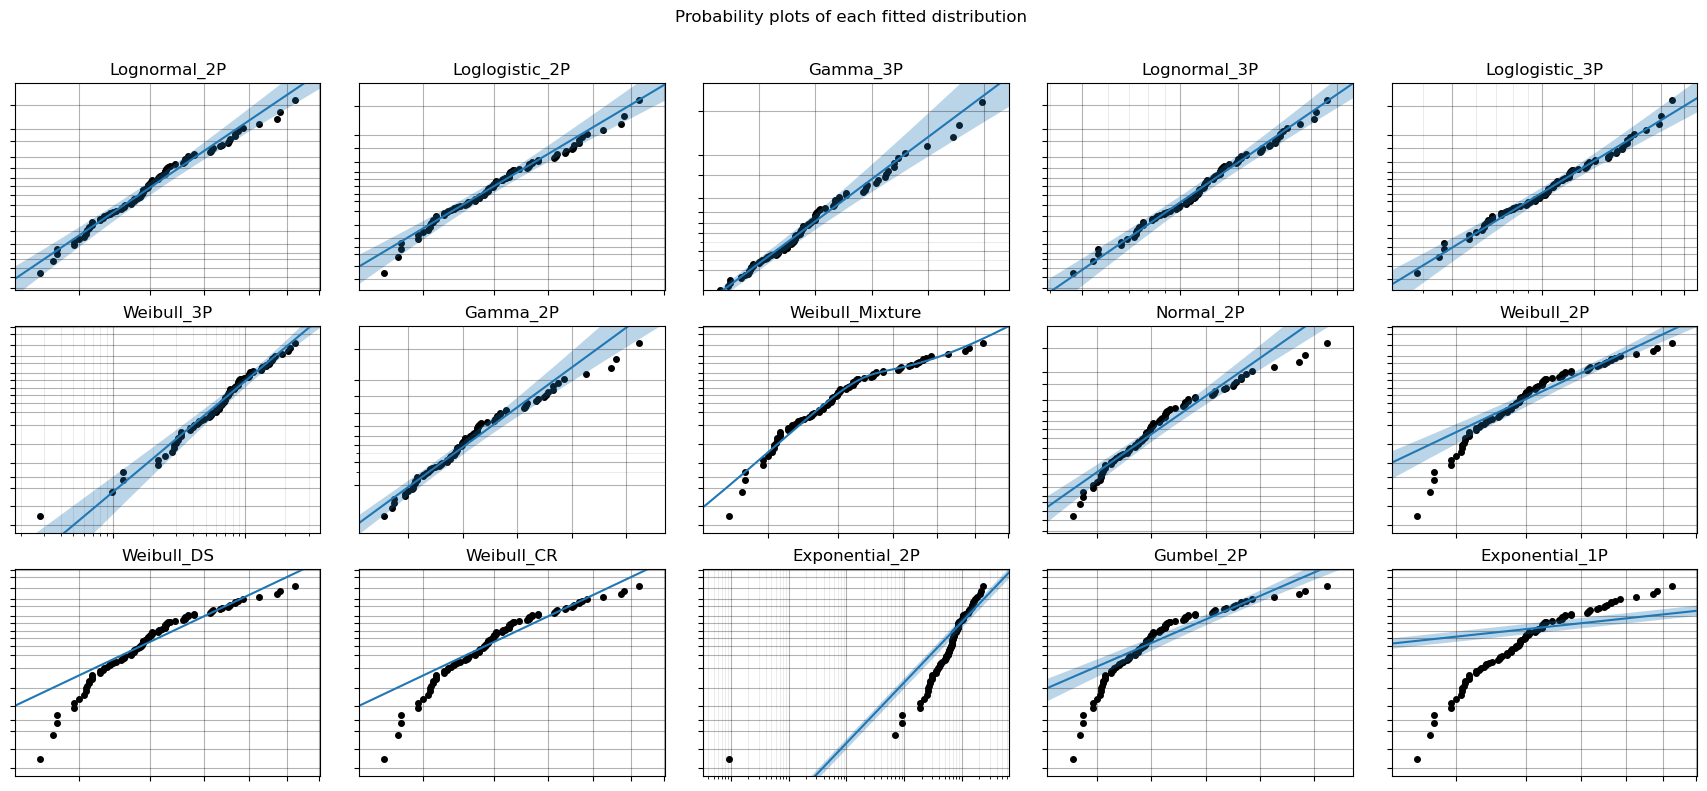

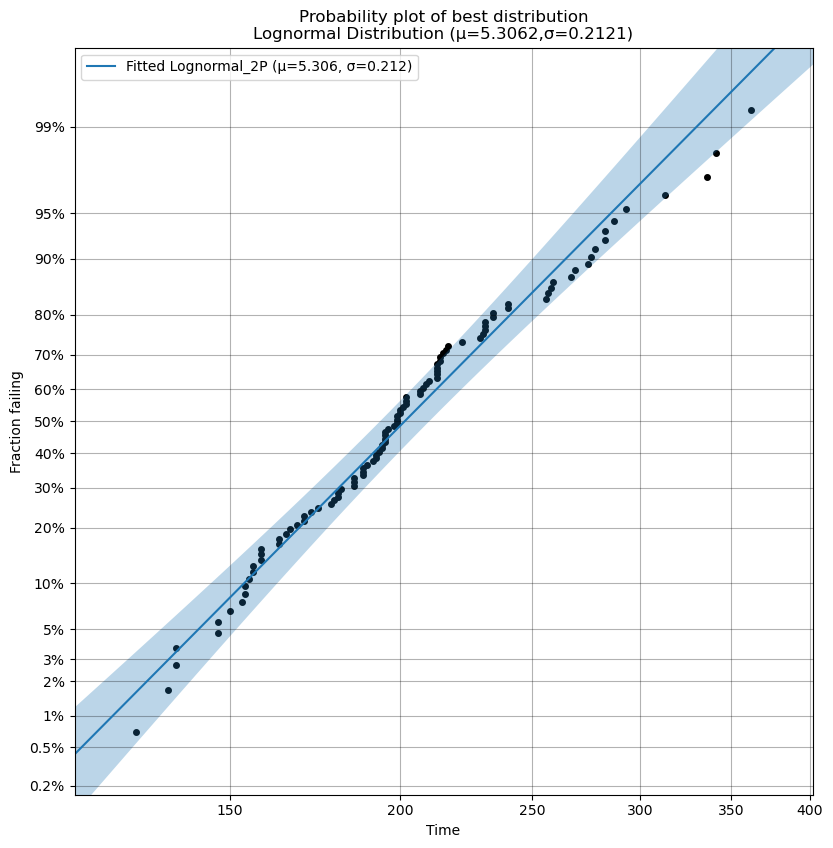

In [ ]:
ttf_data = df_train.groupby('engine')['cycle'].max().values
results = Fit_Everything(failures=ttf_data)
plt.show()

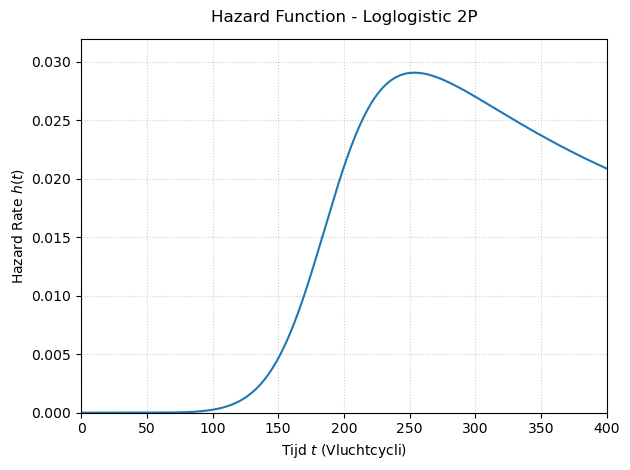

In [3]:
dist = Loglogistic_Distribution(alpha=199.813, beta=8.3708)
dist.HF(xmax=400)
plt.title('Hazard Function - Loglogistic 2P', fontsize=12, pad=12)
plt.xlabel('Tijd $t$ (Vluchtcycli)', fontsize=10)
plt.ylabel('Hazard Rate $h(t)$', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

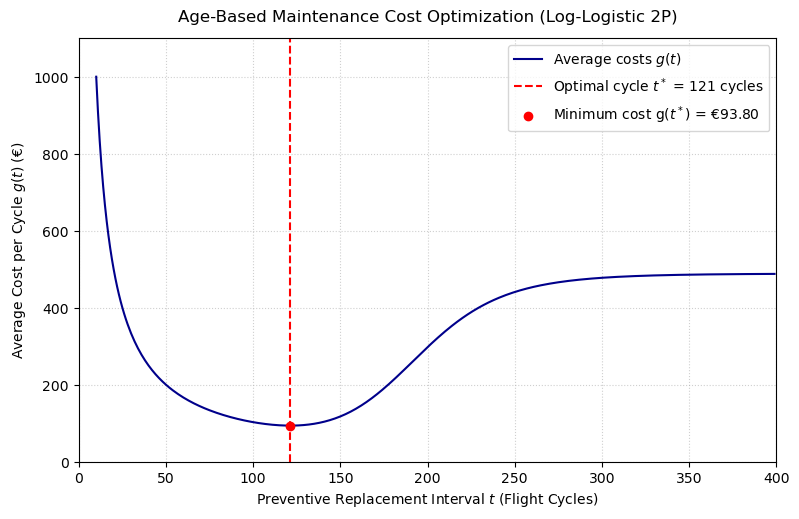

In [28]:
import numpy as np
from scipy.integrate import quad

alpha_value = 199.813  
beta_value = 8.3708    
cp = 10000          # Preventive costs
cf = 100000         # Corrective costs

def loglogistic(t):
    t = float(t)
    dist = Loglogistic_Distribution(alpha=alpha_value, beta=beta_value)
    F_t = float(dist.CDF(xvals=t, show_plot=False))
    
    numerator = cp * (1 - F_t) + cf * F_t
    integrated_part = quad(lambda u: u * float(dist.PDF(xvals=u, show_plot=False)), 0, t)[0]

    denominator = t * (1 - F_t) + integrated_part
    
    return float(numerator / denominator)

t_values = np.arange(10, 400, 1)
g_values = np.zeros(len(t_values))
for i in range(len(t_values)):
    g_values[i] = loglogistic(t_values[i])

optimum_idx = np.argmin(g_values)
t_opt = t_values[optimum_idx]
g_opt = g_values[optimum_idx]

plt.figure(figsize=(9, 5.5))
plt.plot(t_values, g_values, label=r'Average costs $g(t)$', color='darkblue')
plt.axvline(x=t_opt, color='red', linestyle='dashed', label=f'Optimal cycle $t^*$ = {t_opt} cycles')
plt.scatter(t_opt, g_opt, color='red', zorder=3, label=f'Minimum cost g($t^*$) = €{g_opt:.2f}')

plt.title('Age-Based Maintenance Cost Optimization (Log-Logistic 2P)', fontsize=12, pad=12)
plt.xlabel('Preventive Replacement Interval $t$ (Flight Cycles)', fontsize=10)
plt.ylabel('Average Cost per Cycle $g(t)$ (€)', fontsize=10)
plt.xlim(0, 400)
plt.ylim(0, max(g_values) * 1.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend();